In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

                                                       Loading the Datasets

In [140]:
#Importing the data
links = pd.read_csv('data/links.csv')
movies = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

                                                  Exploratory Data Analysis

In [141]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [142]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [143]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [144]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [145]:
#Analyzing the shapes of different data-segments
print(links.shape)
print(ratings.shape)
print(tags.shape)
print(movies.shape)

(9742, 3)
(100836, 4)
(3683, 4)
(9742, 3)


In [146]:
#Checking for missing values in the data
print(links.isnull().sum())
print(ratings.isnull().sum())
print(tags.isnull().sum())
print(movies.isnull().sum())

movieId    0
imdbId     0
tmdbId     8
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [147]:
#Checking for duplicates
print(links.duplicated().sum())
print(ratings.duplicated().sum())
print(tags.duplicated().sum())
print(movies.duplicated().sum())

0
0
0
0


In [148]:
#Checking how sparse the data is i.e. in a grid of users vs movies how much % of rows are empty
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
tot_poss = n_users*n_movies
act_ratings = len(ratings)
sparsity = (1 - act_ratings/tot_poss) * 100
print(sparsity)

98.30003169443864


rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


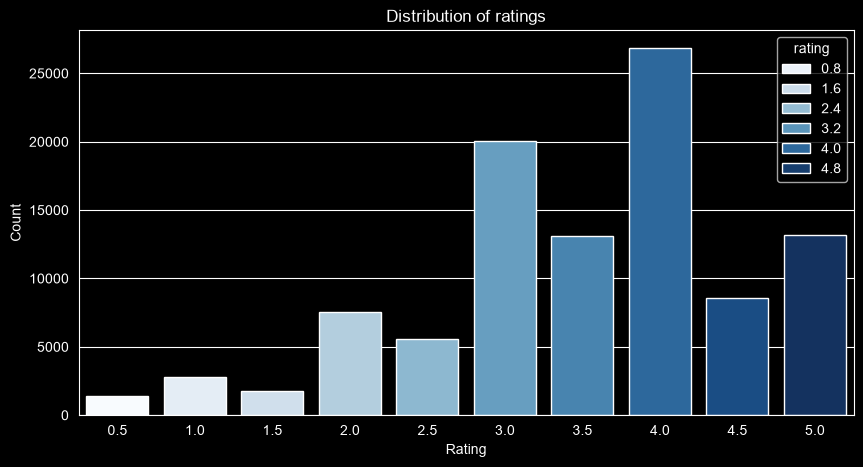

In [149]:
#Visualizing the distribution of ratings
print(ratings['rating'].value_counts().sort_index())

plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=ratings, palette='Blues', hue='rating')
plt.title('Distribution of ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

165.30491803278687
20
2698


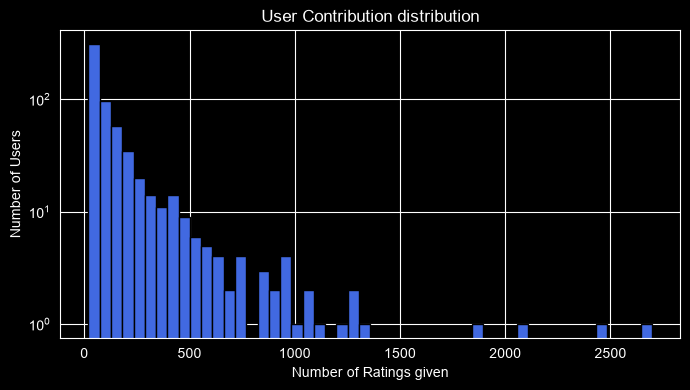

10.369806663924312
1
329


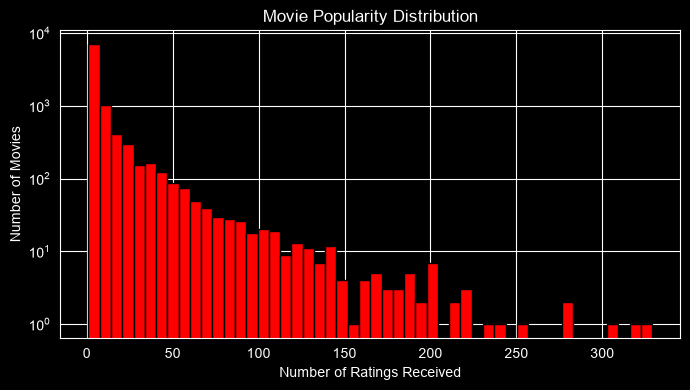

In [150]:
#Analyzing number of ratings per movie and number of ratings per user

#Ratings per user
ratings_per_user = ratings.groupby('userId').size()
print(ratings_per_user.mean())
print(ratings_per_user.min())
print(ratings_per_user.max())

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_user, bins=50, log=True, color='RoyalBlue', edgecolor='black')
plt.title('Histogram of ratings per user')
plt.title('User Contribution distribution')
plt.xlabel('Number of Ratings given')
plt.ylabel('Number of Users')
plt.show()

#Ratings per movie
ratings_per_movie = ratings.groupby('movieId').size()
print(ratings_per_movie.mean())
print(ratings_per_movie.min())
print(ratings_per_movie.max())

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_movie, bins=50, log=True, color='Red', edgecolor='black')
plt.title('Histogram of ratings per movie')
plt.title('Movie Popularity Distribution')
plt.xlabel('Number of Ratings Received')
plt.ylabel('Number of Movies')
plt.show()



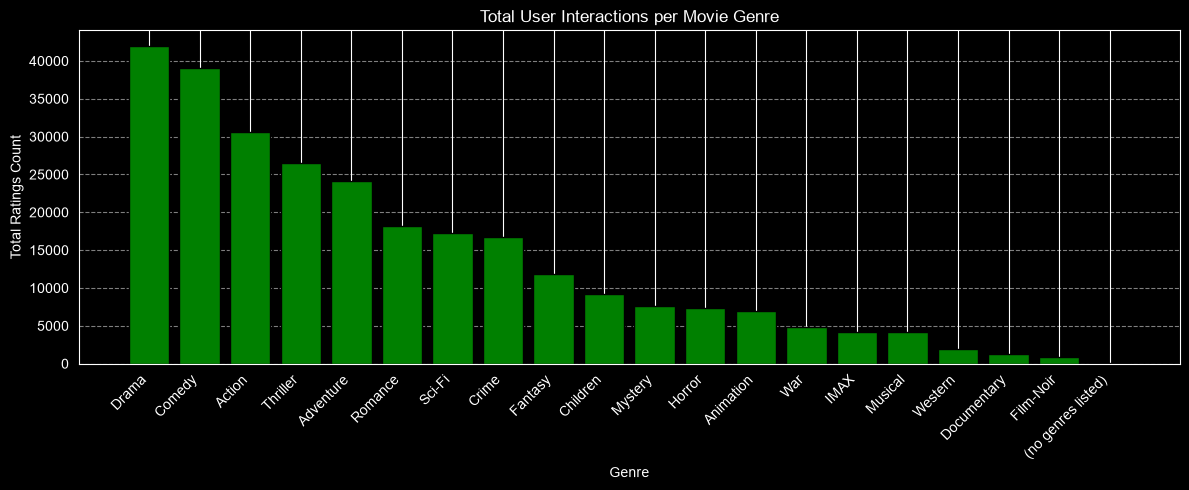

In [151]:
#Analyzing user interactions with different genre

movies['genres_list'] = movies['genres'].str.split('|')
merged = pd.merge(ratings, movies, on='movieId')
merged_genres = [genre for sublist in merged['genres_list'].dropna() for genre in sublist]
merged_genres = np.array(merged_genres)
genre, counts = np.unique(merged_genres, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
genre = genre[sorted_indices]
counts = counts[sorted_indices]
plt.figure(figsize=(12, 5))
plt.bar(genre, counts, color='green', edgecolor='black')
plt.title('Total User Interactions per Movie Genre')
plt.xlabel('Genre')
plt.ylabel('Total Ratings Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

                                                       Preprocessing and Split

In [152]:
#For better recommendations, instead of giving the users recommendations from all possible pool of movies let us restrict ourselves to a threshold on the ratings per user and the ratings per movie

#Let us start with 150 for ratings/user and 15 for ratings/movie (both are almost above avg) and then try fine-tuning them

#Since we are doing a Collaborative Filtering Recommender System, our goal would be to recommend purely based on past user data interaction with a specific movie id rather than Genre or Time-stamp, Tag or Genre which could be used for a content based recommender system

#So we should start by creating a pivot table : a grid of UserID vs MovieID with values in each cell as the rating given by that specific user for that specific movie

In [153]:
test_ratings = (ratings.groupby('userId', group_keys=False).sample(frac=0.2, random_state=42))
train_ratings = ratings.drop(test_ratings.index)
val_ratings = (train_ratings.groupby('userId', group_keys=False).sample(frac=0.125, random_state=42))
train_ratings = train_ratings.drop(val_ratings.index)
user_counts = train_ratings['userId'].value_counts()
active_users = user_counts[user_counts >= 75].index
train_filtered = train_ratings[train_ratings['userId'].isin(active_users)]

movie_counts = train_filtered['movieId'].value_counts()
popular_movies = movie_counts[movie_counts >= 7].index
train_filtered = train_filtered[train_filtered['movieId'].isin(popular_movies)]
train_filtered = train_filtered.drop_duplicates(subset=['userId', 'movieId'])
print(train_filtered['userId'].nunique())
print(train_filtered['movieId'].nunique())
print(len(train_ratings))
print(len(val_ratings))
print(len(test_ratings))

236
2151
70579
10093
20164


In [154]:
#Constructing the pivot table
user_pt = train_filtered.pivot_table(index='userId', columns='movieId', values='rating')
print(user_pt.shape)

#Checking the new sparsity after filtering
tot_cells = user_pt.shape[0] * user_pt.shape[1]
filled_cells = user_pt.notna().sum().sum()
sparsity = (1 - filled_cells / tot_cells) * 100
print(sparsity)

val_eval = val_ratings[val_ratings['userId'].isin(user_pt.index)& val_ratings['movieId'].isin(user_pt.columns)].copy()
test_eval = test_ratings[test_ratings['userId'].isin(user_pt.index)& test_ratings['movieId'].isin(user_pt.columns)].copy()
print(len(val_eval))
print(len(test_eval))

(236, 2151)
91.14936686917397
6257
12346


                                                Memory Based Collaborative Filtering

The Pearson similarity between users \(u\) and \(v\) is:

$$
s_{uv}
=
\frac{
\displaystyle\sum_{j \in I_{uv}}
(r_{uj}-\bar{r}_u)(r_{vj}-\bar{r}_v)
}{
\sqrt{
\displaystyle\sum_{j \in I_{uv}}
(r_{uj}-\bar{r}_u)^2
}
\sqrt{
\displaystyle\sum_{j \in I_{uv}}
(r_{vj}-\bar{r}_v)^2
}
}
$$

where $(I_{uv}$) is the set of movies rated by both users.

In [155]:
#Using Pearson correlation over cosine because it handles the user's taste very well like if a user rates a max of only 3 even for good movies and a user gives out 5 even for bad movies. This is handled better by Pearson than Cosine Similarity
user_similarity_df = user_pt.T.corr(method='pearson', min_periods=5)
print(user_similarity_df.shape)
user_similarity_df.head(3)
user_means = user_pt.mean(axis=1)
print(user_means.head())

(236, 236)
userId
1     4.430556
4     3.569106
6     3.651007
7     3.300000
10    3.432432
dtype: float64


                                      Memory Based Recommendations and User Rating Prediction

The predicted rating of user \(u\) for movie \(i\) is:

$$
\hat{r}_{ui}
=
\bar{r}_u
+
\frac{
\displaystyle\sum_{v \in N_{u,i}}
s_{uv}\left(r_{vi}-\bar{r}_v\right)
}{
\displaystyle\sum_{v \in N_{u,i}}
\left|s_{uv}\right|
}
$$

where:

- $\hat{r}_{ui}$ = predicted rating of user $u$ for movie $i$
- $\bar{r}_u$ = average rating of target user $u$
- $r_{vi}$ = rating given to movie $i$ by neighbor $v$
- $\bar{r}_v$ = average rating of neighbor $v$
- $s_{uv}$ = Pearson similarity between users $u$ and $v$
- $N_{u,i}$ = set of the most similar users to $u$ who have rated movie $i$

The term $r_{vi}-\bar{r}_v$ represents how much neighbor $v$'s rating differs from their usual rating behavior. These deviations are weighted by the similarity between the neighbor and the target user.

In [156]:
#This function uses the computed Pearson's Correlation data and accordingly makes the rating predictions based on the above formula
def predict_user_rating(user_id,movie_id,user_pt,user_similarity_df,user_means,n_neighbors=20):
    if user_id not in user_pt.index:
        return np.nan
    if movie_id not in user_pt.columns:
        return np.nan
    similarities = user_similarity_df.loc[user_id].drop(user_id)
    similarities = similarities[similarities > 0]
    movie_ratings = user_pt[movie_id].dropna()
    eligible_users = similarities.index.intersection(movie_ratings.index)
    similarities = similarities.loc[eligible_users]
    similarities = similarities.nlargest(n_neighbors)
    if similarities.empty:
        return np.nan
    ratings_values = movie_ratings.loc[similarities.index]
    neighbor_means = user_means.loc[similarities.index]
    rating_deviations = (ratings_values.values- neighbor_means.values)

    numerator = np.dot(similarities.values,rating_deviations)
    denominator = np.sum(np.abs(similarities.values))

    if denominator == 0:
        return np.nan
    prediction = (user_means.loc[user_id]+ numerator / denominator)

    return np.clip(prediction,0.5,5.0)

In [157]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def evaluate_user_cf(eval_data, n_neighbors=20):
    actual = []
    predicted = []
    for row in eval_data.itertuples(index=False):
        pred = predict_user_rating(
            row.userId, row.movieId,
            user_pt, user_similarity_df, user_means,
            n_neighbors=n_neighbors
        )
        if not np.isnan(pred):
            actual.append(row.rating)
            predicted.append(pred)
    if not actual:
        return np.nan, np.nan, 0.0
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    coverage = len(predicted) / len(eval_data)
    return mae, rmse, coverage

In [158]:
#This uses the same Idea as the above function but further double downs on it to get a list fo movie names rather than individual user rating. We still use the same Pearson Coefficient Formula to find the probable rating the user might give based on the neighbours data and in that we select a few candidate movies which are the ones users with simlar liking of movies have seen and then in that choose the ones not in seen by the 'to be recommended' user and then sort them and show the top n(also a parameter)

def get_recommendations_for_any_user(user_id,train_ratings,user_pt,user_similarity_df,user_means,movies_df,top_n=10,n_neighbors=20):
    if user_id not in user_pt.index:
        return f'User {user_id} is not present in the training data.'
    rated_movies = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
    candidate_movies = [movie_id for movie_id in user_pt.columns if movie_id not in rated_movies]
    predictions = []
    for movie_id in candidate_movies:
        prediction = predict_user_rating(user_id,movie_id,user_pt,user_similarity_df,user_means,n_neighbors)

        if not np.isnan(prediction):
            predictions.append((movie_id, prediction))

    if not predictions:
        return 'No recommendations could be generated.'

    predictions.sort(key=lambda x: x[1],reverse=True)
    predictions = predictions[:top_n]
    recommendations = pd.DataFrame(predictions,columns=['movieId', 'predicted_score'])
    recommendations = recommendations.merge(movies_df[['movieId', 'title', 'genres']],on='movieId',how='left')
    return recommendations[['title', 'genres', 'predicted_score']]

                                                  Memory based Sample Recommendation

In [159]:
#Trying out the recommender system on one user
sample_filtered_user = user_pt.index[100]
print(sample_filtered_user)
recommendations = get_recommendations_for_any_user(sample_filtered_user, train_filtered, user_pt, user_similarity_df, user_means, movies, top_n=10, n_neighbors=20)
display(recommendations)

256


,title,genres,predicted_score
0,Singin' in the Rain (1952),Comedy|Musical|Romance,5.000000
1,Midnight Cowboy (1969),Drama,5.000000
2,Guess Who's Coming to Dinner (1967),Drama,5.000000
3,Watership Down (1978),Adventure|Animation|Children|Drama|Fantasy,4.991613
4,Rosencrantz and Guildenstern Are Dead (1990),Comedy|Drama,4.983405
5,Dolores Claiborne (1995),Drama|Thriller,4.980140
6,Yojimbo (1961),Action|Adventure,4.939982
7,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,4.938444
8,Patton (1970),Drama|War,4.933868
9,Dunkirk (2017),Action|Drama|Thriller|War,4.927813


In [160]:
#Testing the similarity(correlation) computation
sample_user = user_pt.index[100]
print(user_similarity_df.loc[sample_user].drop(sample_user).sort_values(ascending=False).head(20))

userId
6      0.784465
282    0.751461
542    0.715009
577    0.707107
221    0.697863
199    0.686442
22     0.683130
326    0.682948
263    0.677771
590    0.638577
233    0.623335
385    0.612372
195    0.610658
169    0.607991
356    0.607470
212    0.561186
594    0.552816
562    0.541659
80     0.535853
280    0.520701
Name: 256, dtype: float64


                                       Memory Based Collaborative Filtering Evaluation Metrics

In [161]:
for k in [10, 20, 30, 40, 50]:
    mae, rmse, coverage = evaluate_user_cf(val_eval, n_neighbors=k)
    print(f"k={k} | MAE={mae:.4f} | "f"RMSE={rmse:.4f} | Coverage={coverage:.4f}")

k=10 | MAE=0.6496 | RMSE=0.8470 | Coverage=0.9995
k=20 | MAE=0.6409 | RMSE=0.8374 | Coverage=0.9995
k=30 | MAE=0.6403 | RMSE=0.8366 | Coverage=0.9995
k=40 | MAE=0.6404 | RMSE=0.8366 | Coverage=0.9995
k=50 | MAE=0.6402 | RMSE=0.8367 | Coverage=0.9995


                                           Memory Based Collaborative Filtering Heat Map

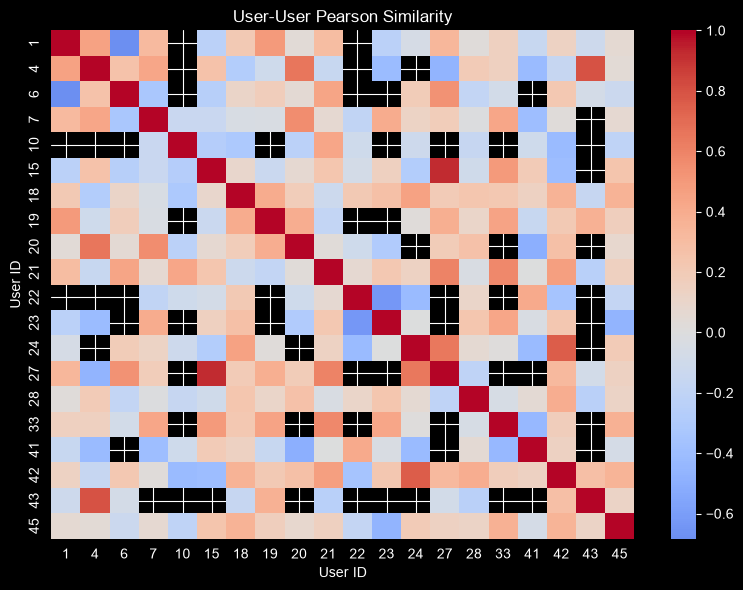

In [162]:
#Basically trying to visualize the correlation between different users, RED means - Highly Similar Movie Preferences, BLUE - Not that much
sample_users = user_similarity_df.index[:20]
plt.figure(figsize=(8, 6))
sns.heatmap(user_similarity_df.loc[sample_users, sample_users],cmap='coolwarm',center=0)
plt.title('User-User Pearson Similarity')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

                                                    Model Based Collaborative Filtering

In [163]:
#Approach is that instead of checking a given user's ratings for all set of movies which is going to be just a fraction of the total movies what we do is we assign a latent vector of finite length to all the movies and to all the users and then based on parameter tuning get a vector which we assume fairly explains the type of movies the user watches and in case of movies the type of users who watch that movie. In this way we start with a random set of vectors and then fine-tune it to get a description of the user's and movie's behavior(we don't know what each value in the vector represents)

                                                            Predicted Rating

For a user (u) and a movie (i), the predicted rating is:

$$
\hat r_{ui}=\mu+b_u+b_i+p_u^Tq_i
$$

where:

$(r_{ui})$: Actual rating given by user (u) to movie (i).

$(\hat r_{ui})$: Predicted rating.

$(\mu)$: Global average rating in the training data.

$(b_u)$: User-specific bias, capturing how much user (u) tends to rate above or below the global average.

$(b_i)$: Movie-specific bias, capturing how much movie (i) tends to be rated above or below the global average.

$(p_u\in\mathbb{R}^k)$: Latent-factor vector representing the learned preference characteristics of user (u).

$(q_i\in\mathbb{R}^k)$: Latent-factor vector representing the learned characteristics of movie (i).

$(k)$: Number of latent factors.

$(p_u^Tq_i)$: Dot product between the user and movie latent vectors, representing their learned compatibility.

                                                   Loss Function with Regularization

For one observed rating, define the regularized squared-error loss as:

$$
\begin{aligned}
J_{ui}={}&
\frac{1}{2}(r_{ui}-\hat r_{ui})^2\
&+\frac{\lambda}{2}
\left(
|p_u|^2+|q_i|^2+b_u^2+b_i^2
\right)
\end{aligned}
$$

where:

$(J_{ui})$: Regularized loss associated with one observed rating.

$(\lambda)$: Regularization coefficient, controlling the penalty on large parameter values.

$(|p_u|^2)$ and $(|q_i|^2)$: Squared Euclidean norms of the latent-factor vectors.

$(b_u^2) and (b_i^2)$: Squared user and movie biases.

The factor (1/2) simplifies differentiation by cancelling the factor of (2) from the squared-error term.

                                                      Individual Partial Derivatives

Since

$$
e_{ui}=r_{ui}-
\left(\mu+b_u+b_i+p_u^Tq_i\right)
$$

the partial derivatives of the regularized loss are:

With respect to the user latent vector:

$$
\boxed{
\frac{\partial J_{ui}}{\partial p_u}
=-e_{ui}q_i+\lambda p_u
}
$$

With respect to the movie latent vector:

$$
\boxed{
\frac{\partial J_{ui}}{\partial q_i}
=-e_{ui}p_u+\lambda q_i
}
$$

With respect to the user bias:

$$
\boxed{
\frac{\partial J_{ui}}{\partial b_u}
=-e_{ui}+\lambda b_u
}
$$

With respect to the movie bias:

$$
\boxed{
\frac{\partial J_{ui}}{\partial b_i}
=-e_{ui}+\lambda b_i
}
$$

The negative error terms arise because the prediction error is the actual rating minus the predicted rating. The regularization terms penalize large parameter values.

                                                         SGD Update Equations

Stochastic Gradient Descent updates parameters using the gradient calculated from one observed rating at a time.

The general update rule is:

$$
\theta\leftarrow\theta-\eta
\frac{\partial J_{ui}}{\partial\theta}
$$

where:

(\theta): A trainable parameter.
(\eta): Learning rate, controlling the size of each update.

Substituting the individual derivatives gives:

User latent vector:

$$
\boxed{
p_u\leftarrow p_u+
\eta(e_{ui}q_i-\lambda p_u)
}
$$

Movie latent vector:

$$
\boxed{
q_i\leftarrow q_i+
\eta(e_{ui}p_u-\lambda q_i)
}
$$

User bias:

$$
\boxed{
b_u\leftarrow b_u+
\eta(e_{ui}-\lambda b_u)
}
$$

Movie bias:

$$
\boxed{
b_i\leftarrow b_i+
\eta(e_{ui}-\lambda b_i)
}
$$

In [179]:
#Chose simple stochastic grad-descent cause it is simple and efficient for this problem in terms of implementation.
#Adam might have performed better but since I implemented from scratch thought it would be fine to implement SGD
#It did perform decently well. So I don't see a major tradeoff here

In [172]:
#Initializing the parameters
n_factors = 10
learning_rate = 0.05
regularization = 0.10
epochs = 20

In [173]:
user_ids = train_filtered['userId'].unique()
movie_ids = train_filtered['movieId'].unique()
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

n_users = len(user_to_idx)
n_movies = len(movie_to_idx)
P = np.random.normal(0.0,0.1,size=(n_users, n_factors))
Q = np.random.normal(0.0,0.1,size=(n_movies, n_factors))
user_bias = np.zeros(n_users)
movie_bias = np.zeros(n_movies)
global_mean = train_filtered['rating'].mean()

In [174]:
training_losses = []
for epoch in range(epochs):
    shuffled = train_filtered.sample(frac=1,random_state=epoch)
    epoch_loss = 0
    for row in shuffled.itertuples(index=False):
        u = user_to_idx[row.userId]
        i = movie_to_idx[row.movieId]
        rating = row.rating
        prediction = global_mean+ user_bias[u]+ movie_bias[i]+ np.dot(P[u], Q[i])
        error = rating - prediction
        user_vector = P[u].copy()
        movie_vector = Q[i].copy()
        P[u] += learning_rate * (error * movie_vector- regularization * user_vector)
        Q[i] += learning_rate * (error * user_vector- regularization * movie_vector)
        user_bias[u] += learning_rate * (error- regularization * user_bias[u])
        movie_bias[i] += learning_rate * (error- regularization * movie_bias[i])
        epoch_loss += error**2
    epoch_loss /= len(shuffled)
    training_losses.append(epoch_loss)

In [175]:
def evaluate_mf(eval_data):
    actual = []
    predicted = []
    for row in eval_data.itertuples(index=False):
        u = user_to_idx.get(row.userId)
        i = movie_to_idx.get(row.movieId)
        if u is None or i is None:
            continue
        pred = (global_mean+ user_bias[u]+ movie_bias[i]+ np.dot(P[u], Q[i]))
        actual.append(row.rating)
        predicted.append(np.clip(pred, 0.5, 5.0))
    if not actual:
        return np.nan, np.nan, 0.0
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    coverage = len(predicted) / len(eval_data)
    return mae, rmse, coverage

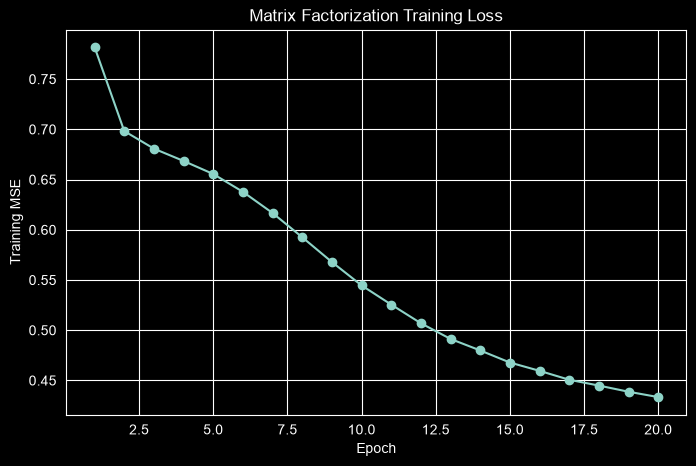

In [176]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1),training_losses,marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.title('Matrix Factorization Training Loss')
plt.show()

In [177]:
mae, rmse, coverage = evaluate_mf(val_eval)
print("Validation MAE:", round(mae, 4))
print("Validation RMSE:", round(rmse, 4))
print("Validation coverage:", round(coverage, 4))

Validation MAE: 0.6318
Validation RMSE: 0.824
Validation coverage: 1.0


In [178]:
user_cf_mae, user_cf_rmse, user_cf_coverage = evaluate_user_cf(test_eval, n_neighbors=30)
mf_mae, mf_rmse, mf_coverage = evaluate_mf(test_eval)
comparison = pd.DataFrame({
    "Model": ["User-User CF", "Matrix Factorization"],
    "MAE": [user_cf_mae, mf_mae],
    "RMSE": [user_cf_rmse, mf_rmse],
    "Coverage (%)": [
        user_cf_coverage * 100,
        mf_coverage * 100
    ]
})
display(comparison.round(4))

,Model,MAE,RMSE,Coverage (%)
0,User-User CF,0.6506,0.8546,99.9676
1,Matrix Factorization,0.6428,0.8433,100.0000
